# Demand Forecasting — End-to-End Pipeline

Predicting weekly per-store `units_sold` using a short window of recent sales history (autoregressive lag features), benchmarked across Random Forest and XGBoost, with hyperparameter tuning via `RandomizedSearchCV`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import xgboost

RANDOM_STATE = 0
pd.set_option('display.width', 120)

## 1. Load the data

In [2]:
df = pd.read_csv('train.csv')
print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')
df.head()

Loaded 150,150 rows, 9 columns


,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52


In [3]:
df.isnull().sum()

record_ID          0
week               0
store_id           0
sku_id             0
total_price        1
base_price         0
is_featured_sku    0
is_display_sku     0
units_sold         0
dtype: int64

## 2. Handle missing values (mean imputation on numeric columns)

In [4]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
for col in numeric_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        fill_value = df[col].mean()
        df[col] = df[col].fillna(fill_value)
        print(f'{col}: filled {n_missing} missing value(s) with mean = {fill_value:.4f}')

total_price: filled 1 missing value(s) with mean = 206.6268


## 3. Parse `week` as a datetime

`week` is parsed as an actual date so that later sorting is chronological.

In [5]:
df['week'] = pd.to_datetime(df['week'], format='%d/%m/%y')
print(df['week'].min(), 'to', df['week'].max())

2011-01-17 00:00:00 to 2013-07-09 00:00:00


## 4. Drop columns not used as model inputs

`store_id` and `week` are kept for now — they're still needed to group and sort correctly before building lag features. `total_price`, `base_price`, `is_featured_sku`, and `is_display_sku` are dropped, framing this as a pure autoregressive model based only on recent sales history.

In [6]:
df = df.drop(columns=['record_ID', 'sku_id', 'total_price', 'base_price',
                       'is_featured_sku', 'is_display_sku'])
df.columns.tolist()

['week', 'store_id', 'units_sold']

## 5. Aggregate and sort chronologically

Group on the real `store_id`/`week` columns, then sort each store's rows chronologically.

In [7]:
df = df.groupby(['store_id', 'week'], as_index=False)['units_sold'].sum()
df = df.sort_values(['store_id', 'week']).reset_index(drop=True)
print(f"After aggregation: {len(df):,} rows ({df['store_id'].nunique()} stores)")
df.head()

After aggregation: 9,880 rows (76 stores)


,store_id,week,units_sold
0,8023,2011-01-17,2344
1,8023,2011-01-24,2034
2,8023,2011-01-31,2058
3,8023,2011-02-07,2152
4,8023,2011-02-14,3512


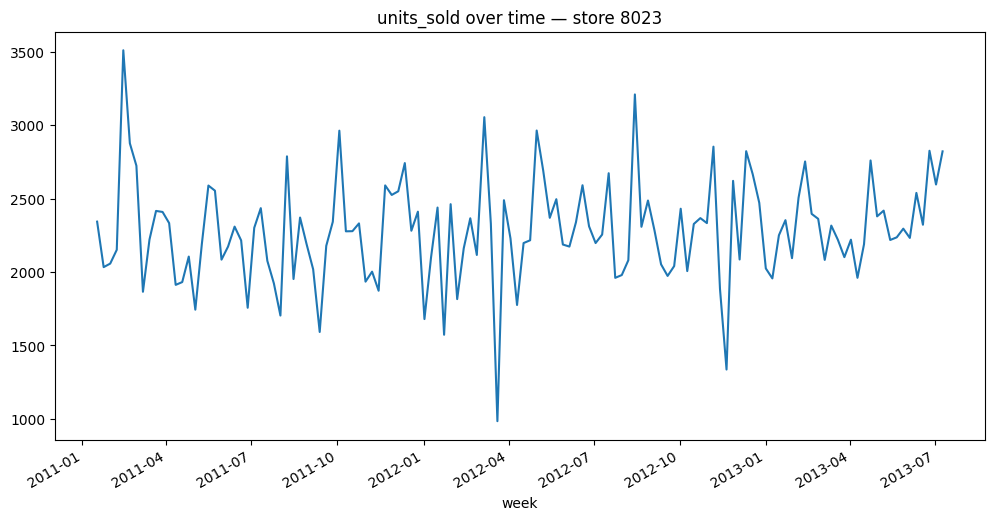

In [8]:
plt.figure(figsize=(12,6))
df[df['store_id'] == df['store_id'].iloc[0]].set_index('week')['units_sold'].plot()
plt.title(f"units_sold over time — store {df['store_id'].iloc[0]}")
plt.show()

## 6. Build lag features (`day_1`–`day_4`)

Each `day_n` column holds the `units_sold` value from `n` weeks earlier for that same store, giving the model a short window of recent sales history to learn from. Lags are computed per store (`.groupby('store_id')`) so a store's lag values never cross into another store's history.

In [9]:
for lag in [1, 2, 3, 4]:
    df[f'day_{lag}'] = df.groupby('store_id')['units_sold'].shift(lag)

before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with incomplete lag history "
      f"(the first 4 weeks of each of the {df['store_id'].nunique()} stores)")
df.head()

Dropped 304 rows with incomplete lag history (the first 4 weeks of each of the 76 stores)


,store_id,week,units_sold,day_1,day_2,day_3,day_4
0,8023,2011-02-14,3512,2152.0,2058.0,2034.0,2344.0
1,8023,2011-02-21,2878,3512.0,2152.0,2058.0,2034.0
2,8023,2011-02-28,2725,2878.0,3512.0,2152.0,2058.0
3,8023,2011-03-07,1866,2725.0,2878.0,3512.0,2152.0
4,8023,2011-03-14,2222,1866.0,2725.0,2878.0,3512.0


## 7. Train/test split — chronological, last 15% held out

A positional (not random/shuffled) split is used deliberately — shuffling time-ordered data before splitting would let the model train on later weeks and get tested on earlier ones, which leaks future information and inflates the apparent accuracy.

In [10]:
feature_cols = ['day_1', 'day_2', 'day_3', 'day_4']
X = df[feature_cols].to_numpy()
y = df['units_sold'].to_numpy().ravel()

split_percentage = 15
test_split = int(len(df) * (split_percentage / 100))
X_train, X_test = X[:-test_split], X[-test_split:]
y_train, y_test = y[:-test_split], y[-test_split:]
print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')

Train: 8,140 rows | Test: 1,436 rows


## 8. Baseline: Random Forest (default hyperparameters)

In [11]:
rf_regressor = RandomForestRegressor(random_state=RANDOM_STATE)
rf_regressor.fit(X_train, y_train)
rf_baseline_r2 = rf_regressor.score(X_test, y_test)
print(f'Random Forest (baseline) R^2: {rf_baseline_r2:.4f}')

Random Forest (baseline) R^2: 0.6601


## 9. Baseline: XGBoost (default hyperparameters)

In [12]:
xgb_regressor = xgboost.XGBRegressor(random_state=RANDOM_STATE)
xgb_regressor.fit(X_train, y_train)
xgb_baseline_r2 = xgb_regressor.score(X_test, y_test)
print(f'XGBoost (baseline) R^2: {xgb_baseline_r2:.4f}')

XGBoost (baseline) R^2: 0.6477


## 10. Hyperparameter tuning — Random Forest via `RandomizedSearchCV`

Samples 10 random combinations out of the full 7,560-combination grid, each evaluated with 3-fold cross-validation (30 total fits) — far cheaper than a full grid search (22,680 fits), while still landing near the best region of the search space.

In [13]:
n_estimators = [int(x) for x in np.linspace(start=50, stop=250, num=10)]
max_features = ['sqrt', 1.0]
max_depth = [int(x) for x in np.linspace(10, 120, num=20)]
max_depth.append(None)
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]
bootstrap = [True, False]

random_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'bootstrap': bootstrap,
}
print(random_grid)

{'n_estimators': [50, 72, 94, 116, 138, 161, 183, 205, 227, 250], 'max_features': ['sqrt', 1.0], 'max_depth': [10, 15, 21, 27, 33, 38, 44, 50, 56, 62, 67, 73, 79, 85, 91, 96, 102, 108, 114, 120, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}


In [14]:
rf = RandomForestRegressor(random_state=RANDOM_STATE)
rf_random = RandomizedSearchCV(
    estimator=rf, param_distributions=random_grid,
    n_iter=10, cv=3, verbose=1, random_state=RANDOM_STATE, n_jobs=-1
)
rf_random.fit(X_train, y_train)
rf_random.best_params_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'n_estimators': 205,
 'min_samples_split': 10,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 91,
 'bootstrap': True}

In [15]:
best_random = rf_random.best_estimator_
y_pred = best_random.predict(X_test)

## 11. Final evaluation — R² and Adjusted R²

In [16]:
r2 = best_random.score(X_test, y_test)
n, k = len(y_test), X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f'R^2 Score (tuned Random Forest):          {r2:.4f}')
print(f'Adjusted R^2 Score (tuned Random Forest):  {adj_r2:.4f}')

print('\n--- Summary of all models ---')
print(f'Random Forest (default):  R^2 = {rf_baseline_r2:.4f}')
print(f'XGBoost (default):        R^2 = {xgb_baseline_r2:.4f}')
print(f'Random Forest (tuned):    R^2 = {r2:.4f}  (Adjusted R^2 = {adj_r2:.4f})')

R^2 Score (tuned Random Forest):          0.6738
Adjusted R^2 Score (tuned Random Forest):  0.6729

--- Summary of all models ---
Random Forest (default):  R^2 = 0.6601
XGBoost (default):        R^2 = 0.6477
Random Forest (tuned):    R^2 = 0.6738  (Adjusted R^2 = 0.6729)


## 12. Predicted vs. actual — a mid-range slice of the test set

A middle slice (not just the tail) is plotted as a sanity check against a model that just predicts something close to the average every time — a flat line that would still get a deceptively okay R², but visibly wouldn't track real sales fluctuations.

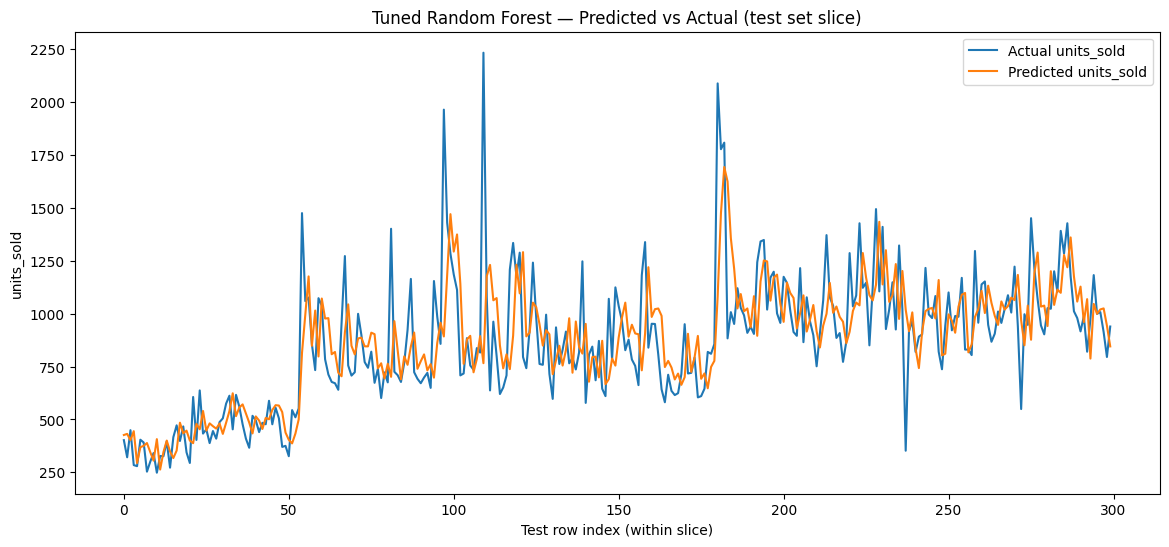

In [17]:
plt.figure(figsize=(14, 6))
lo, hi = 500, min(800, len(y_test))
plt.plot(y_test[lo:hi], label='Actual units_sold')
plt.plot(y_pred[lo:hi], label='Predicted units_sold')
plt.legend()
plt.title('Tuned Random Forest — Predicted vs Actual (test set slice)')
plt.xlabel('Test row index (within slice)')
plt.ylabel('units_sold')
plt.savefig('final.png')
plt.show()